# Autoencoder Anomaly Detector

We build an Autoencoder anomaly detection system finetuning hyperparameters and threshold for optimal anomaly recognition.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import copy
import os

from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch

from common.plots import plot_anomaly_distribution, plot_fbeta_vs_threshold, plot_performance_curves, plot_reconstructions, plot_loss
from common.autoencoder.evaluation import score_images, get_reconstructions, print_metrics
from common.autoencoder.training import train_autoencoder
from common.autoencoder.autoencoder import Autoencoder
from common.io import load_and_split_mnist
from common.finetuning import optimize_via_zooming_grid, optimize_fbeta_threshold
from common.config import MNIST_RAW_PATH, FIGS_DIR, DATA_WEIGHTS_DIR
from common.utils import set_seed

from typing import Tuple, Dict, Any, Callable, Type
from torch.optim import Optimizer
from torch import Tensor

SAVE_DIR = FIGS_DIR / "autoencoder"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
DATA_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
SEED = 42
rs = set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
train_normal, val_normal, val_anomaly, test_normal, test_anomaly = load_and_split_mnist(
    mnist_path=MNIST_RAW_PATH,
    val_anomaly_digit=8,
    test_anomaly_digit=4,
    random_seed=SEED
)

print("Train splits:")
print(f"train_normal: \tX={train_normal[0].shape}, y={train_normal[1].shape}")

print("\nValidation splits:")
print(f"val_normal:   \tX={val_normal[0].shape}, y={val_normal[1].shape}")
print(f"val_anomaly:  \tX={val_anomaly[0].shape}, y={val_anomaly[1].shape}")

print("\nTest splits:")
print(f"test_normal:  \tX={test_normal[0].shape}, y={test_normal[1].shape}")
print(f"test_anomaly: \tX={test_anomaly[0].shape}, y={test_anomaly[1].shape}")

Train splits:
train_normal: 	X=torch.Size([44304, 784]), y=torch.Size([44304, 10])

Validation splits:
val_normal:   	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
val_anomaly:  	X=torch.Size([974, 784]), y=torch.Size([974, 10])

Test splits:
test_normal:  	X=torch.Size([4022, 784]), y=torch.Size([4022, 10])
test_anomaly: 	X=torch.Size([982, 784]), y=torch.Size([982, 10])


In [4]:
train_images = train_normal[0].reshape(train_normal[0].shape[0], 1, 28, 28)

train_dataset = TensorDataset(train_images, train_normal[1])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=2048,
    shuffle=True,
    generator=torch.Generator(device="cpu").manual_seed(SEED),
    num_workers=os.cpu_count(),
    pin_memory=True
)

## Autoencoder arhictecture construction and tuning

We start with a basic convolutional autoencoder that will serve as a base for architecture optimization.

Core Configuration:

- Anomaly score: MSE
- Latent Dimension: tuned \
  Since we do not know what latent dimentionality will prove to be the most effective we will tune it in the range [2-8].
- Activation Function: LeakyReLU \
  We select LeakyReLU as an activation function since it is still computationally efficient, has no vanishing gradient, and fixes the dying neuron problem.

Layer & Parameter Hyperparameters:

- Kernel Size = 3 \
  We set kernel size = 3 to keep kernels computationally efficient without reducing the effective receptive field which grows exponentially with network depth. Additionally, odd kernels make spatial information capture much better by having a perfect center pixel.
- Stride = 2 \
  We set step size (stride) = 2 in order to force the network to extract hierarchical ideas by downsampling the spatial dimensions of the input with each layer.
- Padding = 1 \
  We set padding = 1 in order to allow the downsampling of the spatial dimensions to be symmetric with an odd kernel.
- Convolution Layers Depth = 2 \
  The depth of the encoder/decoder convolutional layers is set to 2 in order to preserve integer division of the spatial dimensions of the input (28 => 14 => 7).

Final Architecture Design:

- Encoder: Conv2d+LeakyReLU[1 -> 16 -> 32] -> Flatten -> Linear+LeakyReLU[32x7x7 -> lat_dim]
- Decoder: Linear+LeakyReLU[lat_dim -> 32x7x7] -> Unflatten -> ConvTranspose2d+LeakyReLU[32 -> 16 -> 1]

In [5]:
# other parameters are set by default in custom built Autoencoder class
autoencoder_kwargs = {
    "conv_channel_sizes": [1, 16, 32],
    "lin_channel_sizes": [128, 32, 8], # last element corresponds to latent dimension
}

criterion_fn = nn.functional.mse_loss
optimizer_cls = torch.optim.Adam
optimizer_kwargs = {
    "lr": 5e-3
}

In [6]:
def optimize_ae(
    model_cls: Autoencoder,
    autoencoder_kwargs: Dict[str, Any],
    train_loader: DataLoader,
    criterion_fn: Callable[[Tensor, Tensor], Tensor],
    optimizer_cls: Type[Optimizer],
    optimizer_kwargs: Dict[str, Any],
    device: torch.device,
    val_normal_X: Tensor,
    val_anomaly_X: Tensor,
    dim_min: int,
    dim_max: int,
    random_state: int = 42,
    verbose: bool = True,
) -> Tuple[int, float, Dict[str, Any]]:
    val_normal_X = val_normal_X.to(device)
    val_anomaly_X = val_anomaly_X.to(device)

    epoch_losses_per_model = {
        "lat_dim": [],
        "losses": []
    }

    def ae_score_callback(latent_dim: float) -> Tuple[np.ndarray, np.ndarray]:
        dim_int = int(latent_dim)

        set_seed(random_state)
        train_loader.generator.manual_seed(random_state)

        current_kwargs = copy.deepcopy(autoencoder_kwargs)
        current_kwargs["lin_channel_sizes"][-1] = dim_int

        model = model_cls(
            **current_kwargs
        ).to(device)

        optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)

        losses = train_autoencoder(
            model = model,
            train_loader = train_loader,
            criterion_fn = criterion_fn,
            optimizer = optimizer,
            device = device,
            loss_eps = 1e-3,
            patience = 5,
            max_epochs = 40,
            corruption_fn = None,
            verbose = verbose
        )

        epoch_losses_per_model["lat_dim"].append(dim_int)
        epoch_losses_per_model["losses"].append(losses)

        val_normal_scores = score_images(model, val_normal_X, device, criterion_fn = criterion_fn)
        val_anomaly_scores = score_images(model, val_anomaly_X, device, criterion_fn = criterion_fn)

        return val_normal_scores, val_anomaly_scores

    best_dim, best_auc, history = optimize_via_zooming_grid(
        score_fn = ae_score_callback,
        param_min = dim_min,
        param_max = dim_max,
        size = (dim_max - dim_min + 1),
        depth = 1,
        param_name = "lat_dim",
        is_integer = True,
        verbose = verbose
    )

    return int(best_dim), best_auc, history

best_dim, best_auc, history = optimize_ae(
    model_cls = Autoencoder,
    autoencoder_kwargs = autoencoder_kwargs,
    train_loader = train_loader,
    criterion_fn = criterion_fn,
    optimizer_cls = optimizer_cls,
    optimizer_kwargs = optimizer_kwargs,
    device = device,
    val_normal_X = val_normal[0],
    val_anomaly_X = val_anomaly[0],
    dim_min = 2,
    dim_max = 16,
    random_state = SEED,
    verbose = True
)

print(f"Best Latent Dimension: {best_dim} with PR AUC: {best_auc:.5e}")


Zoom Step 1/1 Interval: [2.0000, 16.0000]
lat_dim    | PR AUC    


[Early Stopped at Epoch 29]: : 29 epoch [00:21,  1.35 epoch/s, Loss=3.553e-02, Best=3.635e-02, Patience=5/5]


2.0000     | 0.6133    


[Early Stopped at Epoch 27]: : 27 epoch [00:19,  1.37 epoch/s, Loss=2.985e-02, Best=3.083e-02, Patience=5/5]


3.0000     | 0.7108    


...

14.0000    | 0.7300    


[Early Stopped at Epoch 31]: : 31 epoch [00:29,  1.07 epoch/s, Loss=1.184e-02, Best=1.213e-02, Patience=5/5]


15.0000    | 0.7472    


[Early Stopped at Epoch 30]: : 30 epoch [00:33,  1.11s/ epoch, Loss=1.073e-02, Best=1.118e-02, Patience=5/5]

16.0000    | 0.7471    
Best Latent Dimension: 9 with PR AUC: 8.25488e-01


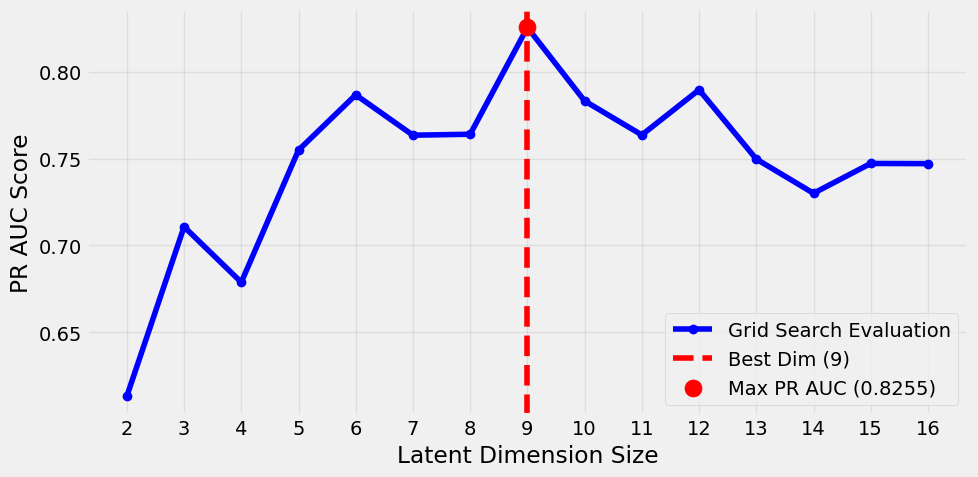

In [14]:
sorted_pairs = sorted(zip(history["lat_dim"], history["auc"]))
sorted_dims, sorted_aucs = zip(*sorted_pairs)

plt.style.use('fivethirtyeight')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sorted_dims, sorted_aucs, marker='o', linestyle='-', color='b', label='Grid Search Evaluation')
ax.axvline(x=best_dim, color='r', linestyle='--', label=f'Best Dim ({best_dim})')
ax.scatter(best_dim, best_auc, color='r', s=150, zorder=5, label=f'Max PR AUC ({best_auc:.4f})')
# ax.set_title('Latent Dimension Optimization vs. Validation PR AUC')
ax.set_xlabel('Latent Dimension Size')
ax.set_ylabel('PR AUC Score')
ax.set_xticks(sorted_dims)
ax.grid(True, alpha=0.5)
ax.legend()
fig.tight_layout()
plt.show()

fig.savefig(SAVE_DIR / "ae_lat_dim_vs_prauc.png", dpi=300, bbox_inches="tight")

In [8]:
autoencoder_kwargs["lin_channel_sizes"][-1] = best_dim

model = Autoencoder(**autoencoder_kwargs).to(device)
optimizer = optimizer_cls(model.parameters(), **optimizer_kwargs)

losses = train_autoencoder(
    model = model,
    train_loader = train_loader,
    criterion_fn = criterion_fn,
    optimizer = optimizer,
    device = device,
    loss_eps = 1e-4,
    patience = 5,
    max_epochs = 100,
    corruption_fn = None,
    verbose = True
)

[Early Stopped at Epoch 84]: : 84 epoch [01:03,  1.31 epoch/s, Loss=1.138e-02, Best=1.144e-02, Patience=5/5]


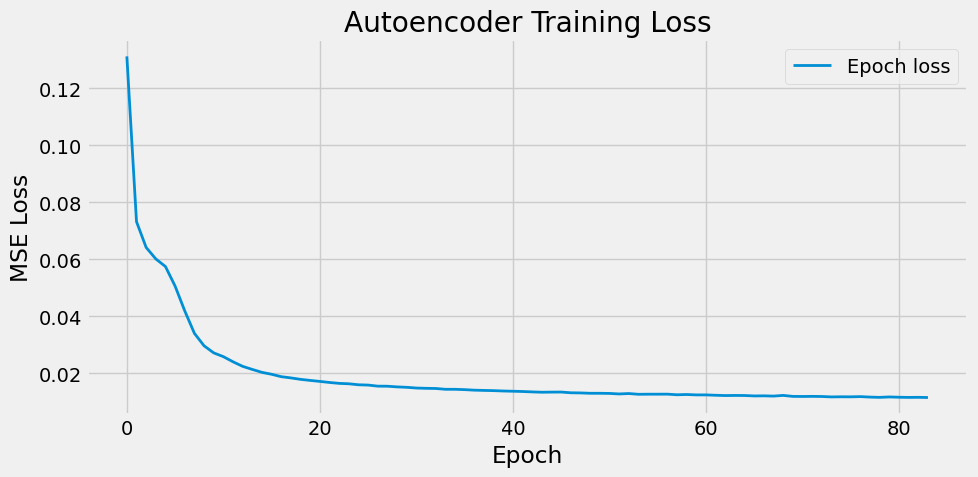

In [9]:
plot_loss(
    losses,
    loss_prefix = "MSE ",
    save_path = SAVE_DIR / "ae_best_model_epoch_loss.png"
)

--- Evaluation Metrics ---
Best threshold for F2.0-score: 0.022566
Accuracy:  0.9089
Precision: 0.6941
Recall:    0.9528
F2.0 score:  0.8867

Confusion matrix:
[[3613  409]
 [  46  928]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9874    0.8983    0.9408      4022
         1.0     0.6941    0.9528    0.8031       974

    accuracy                         0.9089      4996
   macro avg     0.8408    0.9255    0.8719      4996
weighted avg     0.9302    0.9089    0.9139      4996



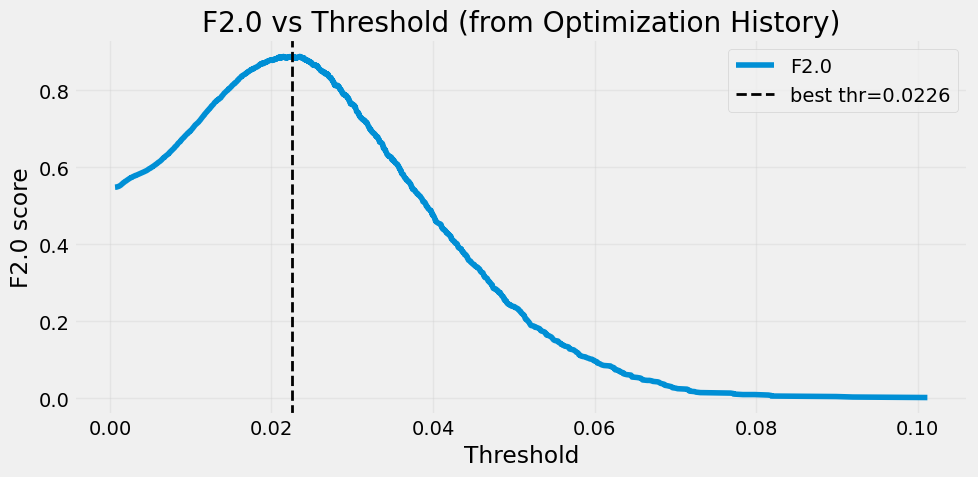

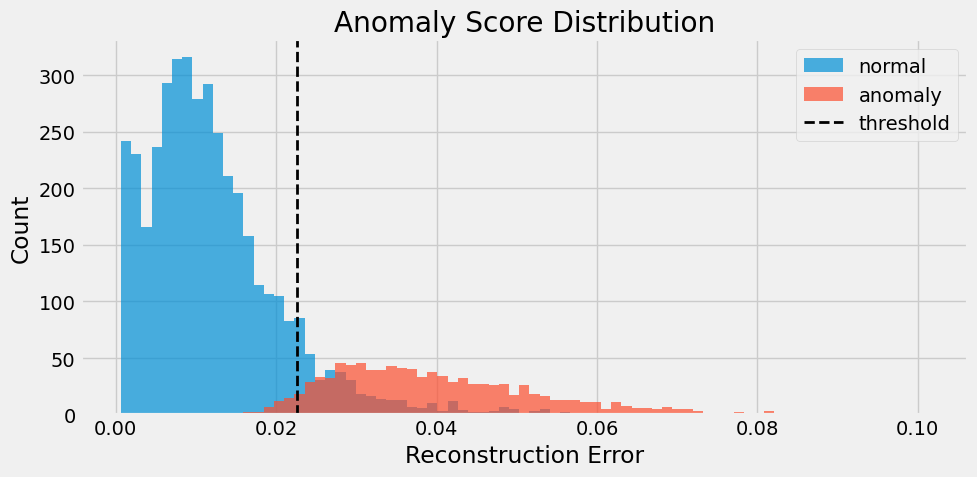

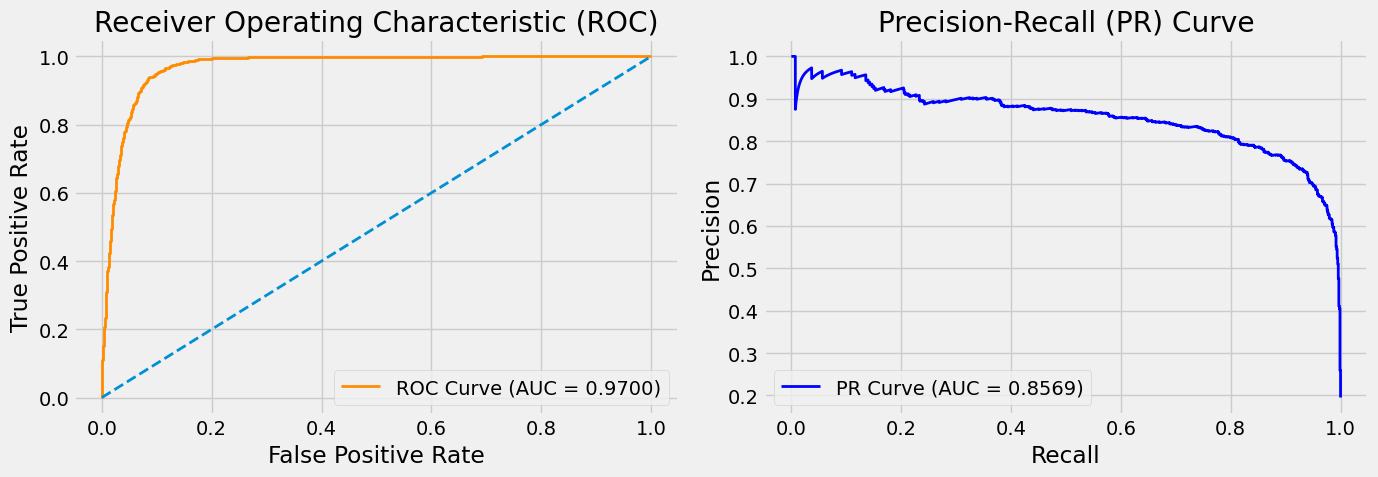

In [10]:
normal_scores = score_images(model, val_normal[0], device=device)
anomaly_scores = score_images(model, val_anomaly[0], device=device)

beta = 2.0
best_threshold, best_results = optimize_fbeta_threshold(
    val_normal_scores=normal_scores,
    val_anomaly_scores=anomaly_scores,
    beta = beta
)

print_metrics(
    y_true = best_results["y_true"],
    y_scores = best_results["y_scores"],
    threshold = best_threshold,
    beta = beta
)

plot_fbeta_vs_threshold(best_results['thresholds'], best_results['fbeta_vals'], best_threshold, beta, save_path=SAVE_DIR / f"ae_f{beta}_vs_threshold.png")
plot_anomaly_distribution(normal_scores, anomaly_scores, best_threshold, save_path=SAVE_DIR / "ae_anomaly_score_distribution.png")
plot_performance_curves(best_results["y_true"], best_results["y_scores"], save_path=SAVE_DIR / "ae_performance_curves.png")

In [11]:
config_checkpoint = {
    "autoencoder_kwargs": autoencoder_kwargs,
    "optimizer_kwargs": optimizer_kwargs,
    "criterion_fn": criterion_fn,
    "corruption_fn": None,
}

train_checkpoint = {
    "weights": model.state_dict(),
    "losses": losses,
    "best_threshold": best_threshold,
    "beta": beta,
    "best_results": best_results
}

torch.save(train_checkpoint, DATA_WEIGHTS_DIR / "ae_base_train.pt")
torch.save(config_checkpoint, DATA_WEIGHTS_DIR / "ae_base_config.pt")

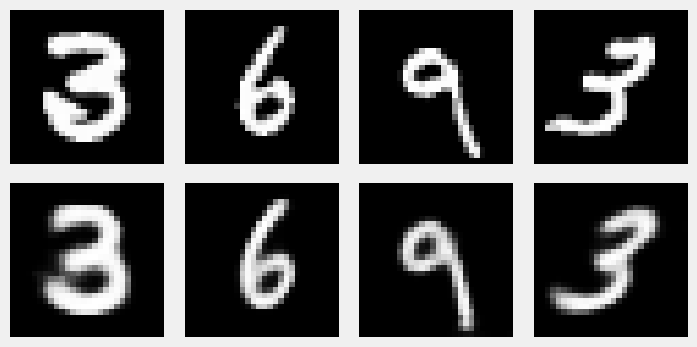

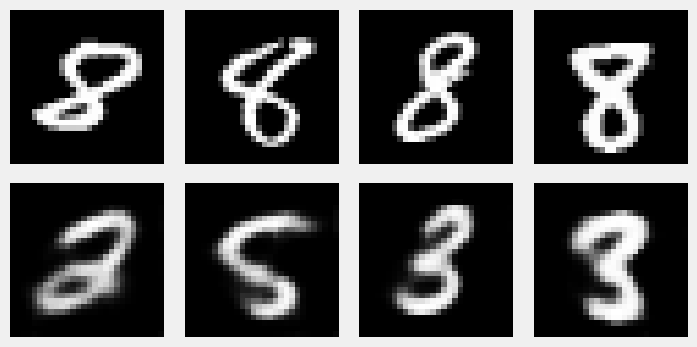

In [ ]:
val_normal_og, val_normal_rec = get_reconstructions(model, val_normal[0][:4], device)
val_anomaly_og, val_anomaly_rec = get_reconstructions(model, val_anomaly[0][:4], device)

# Reconstruction examples for val_normal
plot_reconstructions(val_normal_og, val_normal_rec, '', save_path=SAVE_DIR / 'ae_rec_val_normal.png')

# Reconstruction examples for val_anomaly
plot_reconstructions(val_anomaly_og, val_anomaly_rec, '', save_path=SAVE_DIR / 'ae_rec_val_anomaly.png')